#**Context**

Credit card fraud is a high-stakes problem where even a small number of missed fraud cases can lead to significant financial loss, customer frustration, chargeback costs, and reputational risk. At the same time, flagging legitimate transactions as fraud creates friction—declines, verification steps, and poor customer experience. Because fraud is rare compared to normal transactions, this is an imbalanced classification problem where naive “accuracy” can look great while still failing the business.

#**Objective**

Build and evaluate a binary classification model that predicts whether a transaction is **fraudulent or legitimate**, using historical transaction data. The model should:
* Accurately identify fraudulent transactions (high recall) while keeping false alarms manageable (reasonable precision).
* Use appropriate imbalanced metrics (PR-AUC, precision/recall, F1) rather than accuracy alone.
* Support an operational decision threshold aligned with business costs (e.g., higher recall if fraud losses are costly).
* Provide interpretable insights (feature importance / drivers) and a practical deployment approach (monitoring drift, recalibration, periodic retraining).

#**Dataset Structure**
* **Shape:** 284,807 rows × 31 columns
* **Features:**
  * Time
  * Amount
  * V1-V28 (these V-features are typically PCA-transformed variables in this classic fraud dataset)
* **Target:** Class (0 = normal, 1 = fraud)
* **Missing values:** 0 across all columns (no imputation needed)



**Import Required Libraries**

In [3]:
from datasets import load_dataset
from typing import cast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

from google.colab import userdata

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import warnings
warnings.filterwarnings("ignore")

In [4]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
print("HF_TOKEN set:", os.environ["HF_TOKEN"][:8] + "...")

HF_TOKEN set: hf_AKKQA...


**Load dataset from Hugging Face**


In [5]:
ds = load_dataset("David-Egea/Creditcard-fraud-detection")

README.md:   0%|          | 0.00/188 [00:00<?, ?B/s]

creditcard.csv:   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/284807 [00:00<?, ? examples/s]

**Convert to pandas**

In [6]:
df = ds["train"].to_pandas()

####**Basic Checks (Imbalance + missing + types)**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:

print("Shape after drop_duplicates:", df.shape)
print("Fraud rate after drop:", df["Class"].mean())

Shape after drop_duplicates: (284807, 31)
Fraud rate after drop: 0.001727485630620034


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Observations**
* **Amount** has a big max (25691.16), so it’s skewed (typical).
* **Class** mean ≈ 0.001727 → this implies roughly 0.17% fraud (highly imbalanced).

**Check for duplicates**

In [ ]:
df.duplicated().sum()

np.int64(1081)

**Check for missing rows**

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**Confirms class imbalance counts**

In [ ]:
class_counts = df["Class"].value_counts()
class_ratio = df["Class"].value_counts(normalize=True)
print(class_counts)
print(class_ratio)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


**Observations**

Class imbalance (high-stakes, highly imbalanced)
* Legit (0): 284,315
* Fraud (1): 492
* Fraud rate ≈ 0.1727% → about 1 fraud per ~579 transactions



**Remove duplicates**

In [ ]:
df = df.drop_duplicates()
print("Shape after drop_duplicates:", df.shape)
print("Fraud rate after drop:", df["Class"].mean())

Shape after drop_duplicates: (283726, 31)
Fraud rate after drop: 0.001667101358352777


**Before**

Shape: (284807, 31)

Fraud rate: 0.001727485630620034

**After**

Shape: (283726, 31)

Fraud rate:  0.001667101358352777

###**Baseline model + metrics (PR-AUC + recall/precision)**

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())
print("\n")
print("Train counts:\n", y_train.value_counts())
print("Test counts:\n", y_test.value_counts())
print("\n")
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


Train fraud rate: 0.0016653449643140364
Test fraud rate: 0.0016741268107003137


Train counts:
 Class
0    226602
1       378
Name: count, dtype: int64
Test counts:
 Class
0    56651
1       95
Name: count, dtype: int64




(Class
 0    0.998335
 1    0.001665
 Name: proportion, dtype: float64,
 Class
 0    0.998326
 1    0.001674
 Name: proportion, dtype: float64)

**Observations**

What the split confirms
* Train fraud: 378 / 226,980 (~0.1665%)
* Test fraud: 95 / 56,746 (~0.1674%)
  * Stratification worked (rates match closely).

####**Basline: Logistic Regression (class_weight balanced)**

In [ ]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42))
])

baseline.fit(X_train, y_train)
proba = baseline.predict_proba(X_test)[:, 1]
pred_05 = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, proba))
print(classification_report(y_test, pred_05, digits=4))

ROC-AUC: 0.9656548079701293
PR-AUC (Average Precision): 0.6719244530518995
              precision    recall  f1-score   support

           0     0.9998    0.9755    0.9875     56651
           1     0.0564    0.8737    0.1059        95

    accuracy                         0.9753     56746
   macro avg     0.5281    0.9246    0.5467     56746
weighted avg     0.9982    0.9753    0.9860     56746



**Observations**

**ROC-AUC: 0.966**
* Excellent ranking ability overall (good separation of fraud vs legit).
* But ROC-AUC can look great even in imbalanced problems—so we care more about PR-AUC and threshold behavior.

**PR-AUC (Average Precision): 0.672**
* This is good given fraud is ~0.17%.
* PR-AUC is much more informative here than ROC-AUC because it reflects performance on the rare class.

**Classification report at threshold = 0.5**

Fraud class (1):
* Recall = 0.8737 → caught ~83 of 95 frauds
* Precision = 0.0564 → only ~5.6% of flagged transactions are actually fraud

This means most frauds are caught, however, generating a lot of false alarms.

**Back-of-the-envelope confusion matrix (approx)**
* Predicted fraud count ≈ 83 / 0.0564 ≈ 1470 flagged
* True fraud caught ≈ 83
* False positives ≈ 1470 − 83 = 1387
* Missed fraud ≈ 95 − 83 = 12



**Threshold tuning**

Default 0.5 is almost never the right operating point, therefore, a threshold will be choosen based on business goals e.g.:
* maximize recall (minimize missed fraud), or
* keep precision high enough to manage review workload, or
* optimize a cost function (FN cost ≫ FP cost)

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)

# thresholds has length n-1; align arrays
thr = np.append(thresholds, 1.0)

df_thr = pd.DataFrame({
    "threshold": thr,
    "precision": precision,
    "recall": recall
})

# Add F1 at each threshold
df_thr["f1"] = 2 * (df_thr["precision"] * df_thr["recall"]) / (df_thr["precision"] + df_thr["recall"] + 1e-12)

# Show a few useful operating points
targets = [0.90, 0.95, 0.98]  # desired recall levels
for r in targets:
    cand = df_thr[df_thr["recall"] >= r].head(1)
    if not cand.empty:
        print(f"First threshold achieving recall >= {r}:")
        display(cand)

display(df_thr.sort_values("f1", ascending=False).head(10))

First threshold achieving recall >= 0.9:


,threshold,precision,recall,f1
0,2.032002e-26,0.001674,1.0,0.003343


First threshold achieving recall >= 0.95:


,threshold,precision,recall,f1
0,2.032002e-26,0.001674,1.0,0.003343


First threshold achieving recall >= 0.98:


,threshold,precision,recall,f1
0,2.032002e-26,0.001674,1.0,0.003343


,threshold,precision,recall,f1
56664,1.000000,0.878049,0.757895,0.813559
56666,1.000000,0.887500,0.747368,0.811429
56663,1.000000,0.867470,0.757895,0.808989
56665,1.000000,0.876543,0.747368,0.806818
56660,0.999991,0.848837,0.768421,0.806630
56667,1.000000,0.886076,0.736842,0.804598
56662,1.000000,0.857143,0.757895,0.804469
56659,0.999989,0.839080,0.768421,0.802198
56661,0.999996,0.847059,0.757895,0.800000
56658,0.999980,0.829545,0.768421,0.797814


**Observations**

This reveals the common pitfall in threshold selection for extreme imbalance.

Why "recall ≥ 0.90/0.95/0.98” thresholds look crazy:
* threshold ≈ 2.03e-26
* precision ≈ 0.001674
* recall = 1.0

That means: to guarantee very high recall, you set the threshold so low that you flag almost everything as fraud.

This is technically “perfect recall,” but it’s operationally useless because precision collapses.

This happens because precision_recall_curve starts at a threshold so low it labels nearly all samples positive → recall goes to 1.

**Top F1**

Best F1 rows are showing:
* threshold ≈ 0.99998–1.0
* precision ≈ 0.83–0.89
* recall ≈ 0.74–0.77
* F1 ≈ 0.80–0.81

This implies there’s a region where the model is extremely confident and:
* when it predicts fraud, it’s often correct (high precision),
* but it misses more fraud than earlier 0.5 threshold did (recall drops from ~0.87 to ~0.75).

**Interpretation: two different operating modes:**
1. High recall / low precision (catch most fraud, lots of false alarms)
2. High precision / lower recall (fewer false alarms, miss more fraud)



**Operational threshold table**

In [ ]:
thresholds_to_try = [0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9995, 0.9999]

rows = []
for t in thresholds_to_try:
    y_hat = (proba >= t).astype(int)
    flagged = y_hat.sum()
    rows.append({
        "threshold": t,
        "flagged_alerts": int(flagged),
        "flagged_rate": flagged / len(y_test),
        "precision": precision_score(y_test, y_hat, zero_division=0),
        "recall": recall_score(y_test, y_hat, zero_division=0),
        "f1": f1_score(y_test, y_hat, zero_division=0),
    })

pd.DataFrame(rows)

,threshold,flagged_alerts,flagged_rate,precision,recall,f1
0,0.5000,1472,0.025940,0.056386,0.873684,0.105935
1,0.9000,301,0.005304,0.262458,0.831579,0.398990
2,0.9500,174,0.003066,0.436782,0.800000,0.565056
3,0.9900,114,0.002009,0.657895,0.789474,0.717703
4,0.9950,102,0.001797,0.725490,0.778947,0.751269
5,0.9990,98,0.001727,0.744898,0.768421,0.756477
6,0.9995,95,0.001674,0.768421,0.768421,0.768421
7,0.9999,93,0.001639,0.784946,0.768421,0.776596


**Observations**

As threshold increase:
* flag fewer transactions (review workload drops)
* increase precision (more alerts are real fraud)
* lose some recall (you miss more fraud)

Extremes:

**Threshold 0.50 (default)**
* Alerts: 1472 (2.59% of transactions)
* Precision: 0.056
* Recall: 0.874
* Catches most fraud, but creates a ton of false alarms

**Threshold 0.9995 / 0.9999 (high precision)**
* Alerts: 95 / 93 (~0.17% of transactions)
* Precision: 0.768 / 0.785
* Recall: 0.768
* Very manageable review workload and strong precision, but miss ~23% of fraud

**Options for Threshold selection**

Option A: Balanced and very practical (will use as default)

Threshold = 0.995
* Alerts: 102 (0.18%)
* Precision: 0.725
* Recall: 0.779
* F1: 0.751

Interpretation
* Catch ~78% of fraud (about 74 of 95 fraud cases)
* About 1 in 1.38 alerts is real fraud (precision 72.5% is strong)
* Review workload is tiny (102 checks)

Option B: Higher recall while still reasonable workload

Threshold = 0.95
* Alerts: 174 (0.31%)
* Precision: 0.437
* Recall: 0.800
* F1: 0.565

Interpretation
* Catch 80% of fraud (76 of 95)
* Review 174 cases (still very manageable)
* Precision drops (more false positives), but may be acceptable in high-stakes settings


**Summary**

Threshold selection is a business decision. At the default 0.5 threshold, recall is high (0.874) but alert volume is large (2.59% of transactions) and precision is low (0.056). By increasing the threshold, reduce alert volume and improve precision substantially. A practical operating point is 0.995, which flags only 0.18% of transactions (102 alerts), achieves 0.725 precision, and maintains 0.779 recall—balancing fraud capture with manageable review workload.


**Confusion matrix + metrics at threshold 0.995**

In [ ]:
thr = 0.995
y_pred_thr = (proba >= thr).astype(int)

cm = confusion_matrix(y_test, y_pred_thr)
tn, fp, fn, tp = cm.ravel()

print("Threshold:", thr)
print("Confusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nPrecision:", precision_score(y_test, y_pred_thr, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_thr, zero_division=0))

print("\nClassification report:\n", classification_report(y_test, y_pred_thr, digits=4))

Threshold: 0.995
Confusion Matrix [[TN, FP],[FN, TP]]:
 [[56623    28]
 [   21    74]]

Precision: 0.7254901960784313
Recall: 0.7789473684210526

Classification report:
               precision    recall  f1-score   support

           0     0.9996    0.9995    0.9996     56651
           1     0.7255    0.7789    0.7513        95

    accuracy                         0.9991     56746
   macro avg     0.8626    0.8892    0.8754     56746
weighted avg     0.9992    0.9991    0.9992     56746



**Observations (0.995 threshold)**

See below

**Business-efficiency summary**

In [ ]:
total = len(y_test)
alerts = int(y_pred_thr.sum())
fraud_total = int((y_test == 1).sum())

alert_rate = alerts / total
caught = tp
missed = fn

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

alerts_per_fraud = alerts / caught if caught else float("inf")
false_positives_per_fraud = fp / caught if caught else float("inf")

print(f"Total transactions in test: {total}")
print(f"Total fraud in test: {fraud_total}")
print(f"Alerts raised: {alerts} ({alert_rate:.4%} of transactions)")
print(f"Fraud caught (TP): {caught} | Fraud missed (FN): {missed}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f}")
print(f"Alerts per fraud caught: {alerts_per_fraud:.2f}")
print(f"False positives per fraud caught: {false_positives_per_fraud:.2f}")

Total transactions in test: 56746
Total fraud in test: 95
Alerts raised: 102 (0.1797% of transactions)
Fraud caught (TP): 74 | Fraud missed (FN): 21
Precision: 0.725 | Recall: 0.779
Alerts per fraud caught: 1.38
False positives per fraud caught: 0.38


**Observations**
* Fraud prevalence in test set: 95 / 56,746 (0.167%)
* Alerts generated: 102 (0.1797% of all transactions)
* Fraud caught (TP): 74
* Fraud missed (FN): 21
* False positives (FP): 28
* True negatives (TN): 56,623

**Key metrics**
* Precision: 0.725
  * ~73% of flagged transactions are truly fraud
* Recall: 0.779
  * → catches ~78% of fraud
* F1: 0.751 (solid balance)

**Business-efficiency interpretation**
* Alerts per fraud caught: 1.38
  * Only investigate ~1–2 alerts to catch one fraud (very efficient)
* False positives per fraud caught: 0.38
  * For every fraud you catch, you get less than half a false alarm

Accuracy is not the goal in fraud detection because fraud is rare. Precision/recall and PR-AUC are the meaningful metrics.

**Summary**

At a threshold of 0.995, the model flags only 0.18% of transactions (102 alerts out of 56,746), making the solution operationally feasible. It catches 74 of 95 fraud cases (recall 0.779) with strong precision (0.725), meaning roughly 3 out of 4 alerts are true fraud. This yields high review efficiency: only 1.38 alerts are needed to catch one fraud, with 0.38 false positives per fraud caught. This threshold balances fraud prevention with minimal disruption to legitimate customers and manageable manual review workload.



**Non-linear model comparison**


In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]

print("RandomForest ROC-AUC:", roc_auc_score(y_test, proba_rf))
print("RandomForest PR-AUC:", average_precision_score(y_test, proba_rf))

RandomForest ROC-AUC: 0.9472712424828289
RandomForest PR-AUC: 0.8148716048257391


**Random Forest (handles non-linearities, good baseline)**

In [ ]:
target_alerts = 102  # match logistic threshold workload
sorted_scores = np.sort(proba_rf)[::-1]
thr_rf = sorted_scores[target_alerts-1]  # threshold that flags ~102 highest-risk points

y_pred_rf = (proba_rf >= thr_rf).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print("RF threshold (matched alerts):", thr_rf)
print("Alerts:", y_pred_rf.sum())
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rf, zero_division=0))
print("Confusion matrix [[TN,FP],[FN,TP]]:\n", confusion_matrix(y_test, y_pred_rf))

RF threshold (matched alerts): 0.06995128421657913
Alerts: 102
Precision: 0.7647058823529411
Recall: 0.8210526315789474
F1: 0.7918781725888325
Confusion matrix [[TN,FP],[FN,TP]]:
 [[56627    24]
 [   17    78]]


**Observations**

####**Model comparison at the same review workload (~102 alerts)**

**Logistic Regression (Chosen threshold 0.995)**
* Alerts: 102
* Precision: 0.725
* Recall: 0.779
* TP/FP/FN: 74 / 28 / 21

**Random Forest (matched alerts)**
* Alerts: 102
* Precision: 0.765
* Recall: 0.821
* TP/FP/FN: 78 / 24 / 17
* PR-AUC: 0.815 (better)

✅ **Random Forest beats Logistic** under the same operational constraint:
* catches 4 more frauds (78 vs 74)
* produces 4 fewer false alarms (24 vs 28)


**HistGradientBoostingClassifier (Stronger than Random Forest)**

In [ ]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_depth=6,
    max_iter=500,
    random_state=42
)

hgb.fit(X_train, y_train)
proba_hgb = hgb.predict_proba(X_test)[:, 1]

print("HGB ROC-AUC:", roc_auc_score(y_test, proba_hgb))
print("HGB PR-AUC:", average_precision_score(y_test, proba_hgb))

HGB ROC-AUC: 0.7978034484456537
HGB PR-AUC: 0.5841909373930172


**Match alert volume**

In [ ]:
target_alerts = 102
thr_hgb = np.sort(proba_hgb)[::-1][target_alerts-1]
y_pred_hgb = (proba_hgb >= thr_hgb).astype(int)

print("HGB threshold (matched alerts):", thr_hgb)
print("Alerts:", y_pred_hgb.sum())
print("Precision:", precision_score(y_test, y_pred_hgb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_hgb, zero_division=0))
print("F1:", f1_score(y_test, y_pred_hgb, zero_division=0))
print("Confusion matrix [[TN,FP],[FN,TP]]:\n", confusion_matrix(y_test, y_pred_hgb))

HGB threshold (matched alerts): 0.7483915478838079
Alerts: 103
Precision: 0.6407766990291263
Recall: 0.6947368421052632
F1: 0.6666666666666666
Confusion matrix [[TN,FP],[FN,TP]]:
 [[56614    37]
 [   29    66]]


**Observations**

####**Why HGB looked "bad" (and what calibration shows)**

Raw HGB results are weaker:
* PR-AUC: 0.584
* ROC-AUC: 0.798
* Lower precision/recall at matched alerts

After calibration (see below):
* PR-AUC: 0.751
* ROC-AUC: 0.922

**Key Points:**
* **Calibration improves probability quality**, but it usually shouldn’t massively change ranking. The fact that the “raw HGB” ROC-AUC is much lower suggests the HGB model may not be tuned well for this dataset (or needs different hyperparameters / early stopping / class weighting approach).
* The calibration plots also show why this is tricky: fraud is so rare that most probability bins have near-zero observed fraud rate, so calibration curves can look “flat.” That’s normal.

**Calibration curve**

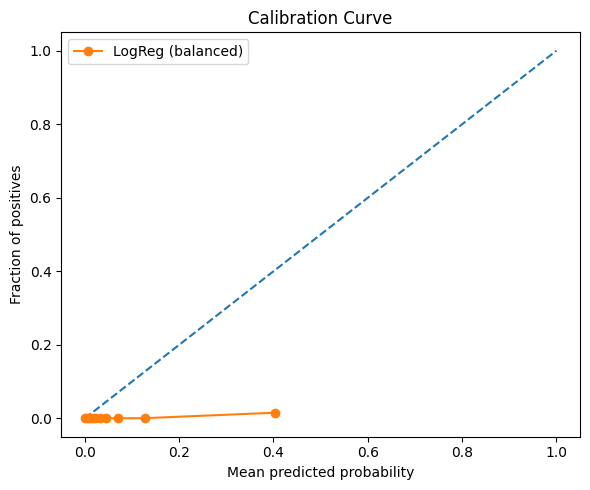

In [ ]:
def plot_calibration(y_true, proba, name):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],"--")

plot_calibration(y_test, proba, "LogReg (balanced)")
# Uncomment if computed these:
# plot_calibration(y_test, proba_rf, "RandomForest")
# plot_calibration(y_test, proba_hgb, "HGB")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")p
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

**Observations**

####**Calibration plot interpretation**

Logistic calibration curve

It sits far below the diagonal because:
* even when the model outputs “0.1–0.4 probability,” the actual fraud rate is still extremely low overall.
* With quantile binning in an imbalanced dataset, many bins still have near-zero positives.



**Calibrate Model (Isotonic/Sigmoid)**

In [ ]:
# Example: calibrate HGB (or RF) using sigmoid (Platt scaling)
hgb_cal = CalibratedClassifierCV(hgb, method="sigmoid", cv=3)
hgb_cal.fit(X_train, y_train)
proba_hgb_cal = hgb_cal.predict_proba(X_test)[:, 1]

print("HGB (calibrated) PR-AUC:", average_precision_score(y_test, proba_hgb_cal))
print("HGB (calibrated) ROC-AUC:", roc_auc_score(y_test, proba_hgb_cal))

HGB (calibrated) PR-AUC: 0.7507690769045297
HGB (calibrated) ROC-AUC: 0.9216012352641147


**Observations**

####**HGB before vs after**

After calibration, the calibrated curve moves slightly closer to “reality,” meaning:
* its predicted probabilities are more aligned with observed outcomes,
* which is useful if you want to interpret scores as probabilities (e.g., “this is a 30% risk”).

✅ **Final model: Random Forest** (with matched-alert thresholding)
* Best PR-AUC and best TP/FP tradeoff at the same review capacity.
* Very easy to explain in business terms: “more fraud caught with fewer alerts.”

✅ **Probability handling:** keep thresholding + (optional) calibration if you need reliable probabilities for risk scoring dashboards.
* If you deploy RF, calibrate RF with CalibratedClassifierCV (sigmoid) and compare.

**Summary**

Compared models under the same operational review workload (~102 alerts on the test set). Logistic Regression at threshold 0.995 achieved 0.725 precision and 0.779 recall (74 frauds caught, 28 false alarms). Random Forest with an alert-matched threshold improved both precision and recall to 0.765 and 0.821 (78 frauds caught, 24 false alarms) and delivered higher PR-AUC (0.815). This makes Random Forest the preferred production model for fraud screening under constrained review capacity. I also evaluated probability calibration; calibration improved probability reliability for gradient boosting, reinforcing that calibrated probabilities are useful for risk scoring, while threshold tuning remains the key operational decision lever.

**Re-polt Calibration**

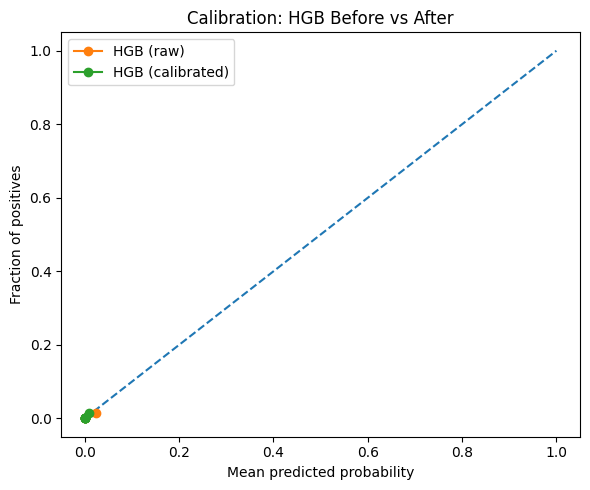

In [ ]:
plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],"--")
plot_calibration(y_test, proba_hgb, "HGB (raw)")
plot_calibration(y_test, proba_hgb_cal, "HGB (calibrated)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration: HGB Before vs After")
plt.legend()
plt.tight_layout()
plt.show()

**Observations**

####**Calibration curve interpretation**

The plot shows both curves hugging near the bottom-left. That's expect becuase:
* Fraud is rare, so the fraction of positives in most bins is near zero.
* With quantile binning, most predictions are small probabilities.

Main takeaway:
* Calibration makes probability estimates more consistent with observed outcomes, but the visual curve may still appear compressed due to extreme imbalance.

**Calibrate Random Forest + compute PR-AUC / ROC-AUC**

In [ ]:
# Ensure proba_rf is a numpy array (silences some type checker warnings)
proba_rf = np.asarray(rf.predict_proba(X_test))[:, 1]

print("RF (raw) PR-AUC:", average_precision_score(y_test, proba_rf))
print("RF (raw) ROC-AUC:", roc_auc_score(y_test, proba_rf))

# Calibrate using sigmoid (Platt scaling). For more flexibility, try method="isotonic".
rf_cal = CalibratedClassifierCV(rf, method="sigmoid", cv=3)
rf_cal.fit(X_train, y_train)

proba_rf_cal = np.asarray(rf_cal.predict_proba(X_test))[:, 1]

print("RF (calibrated) PR-AUC:", average_precision_score(y_test, proba_rf_cal))
print("RF (calibrated) ROC-AUC:", roc_auc_score(y_test, proba_rf_cal))

RF (raw) PR-AUC: 0.8148716048257391
RF (raw) ROC-AUC: 0.9472712424828289
RF (calibrated) PR-AUC: 0.8139363976454738
RF (calibrated) ROC-AUC: 0.9580830551604516


**Observations**

#####**PR-AUC / ROC-AUC (raw vs calibrated)**
* RF (raw): PR-AUC 0.8149, ROC-AUC 0.9473
* RF (calibrated): PR-AUC 0.8139, ROC-AUC 0.9581

What this means:
* PR-AUC stays basically the same (good: calibration doesn’t harm ranking).
* ROC-AUC increased slightly after calibration (can happen, but the key point is: calibration mainly targets probability quality, not ranking quality).

**Matched-alert confusion matrix (102 alerts) — raw vs calibrated**

In [ ]:
def eval_matched_alerts(y_true, proba, target_alerts=102):
    thr = np.sort(proba)[::-1][target_alerts - 1]  # threshold to flag top N
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": float(thr),
        "alerts": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

raw_stats = eval_matched_alerts(y_test, proba_rf, target_alerts=102)
cal_stats = eval_matched_alerts(y_test, proba_rf_cal, target_alerts=102)

print("RF raw @102 alerts:", raw_stats)
print("RF calibrated @102 alerts:", cal_stats)

RF raw @102 alerts: {'threshold': 0.06995128421657913, 'alerts': 102, 'precision': 0.7647058823529411, 'recall': 0.8210526315789474, 'f1': 0.7918781725888325, 'TN': 56627, 'FP': 24, 'FN': 17, 'TP': 78}
RF calibrated @102 alerts: {'threshold': 0.001006657809319698, 'alerts': 102, 'precision': 0.7647058823529411, 'recall': 0.8210526315789474, 'f1': 0.7918781725888325, 'TN': 56627, 'FP': 24, 'FN': 17, 'TP': 78}


**Observations**

#####**Matched-alert confusion matrix @ 102 alerts (raw vs calibrated)**

They're identical:
* TP 78, FP 24, FN 17, TN 56627
* Precision 0.7647, Recall 0.8211

Why identical is expected
* Matched alerts by taking the top 102 scores. Calibration is a monotonic transform in practice (especially sigmoid), so the ordering barely changes, meaning the same 102 transactions get flagged.

**Insights**
* Calibration is for making probabilities more “trustworthy”
* Thresholding/top-N is for operational decisions
* Calibration won’t necessarily change who gets flagged if you choose alerts by rank.

**Why the calibrated threshold looks tiny (0.0010)**

This is normal and actually a great teachable moment:
* In a dataset where base fraud rate is ~0.17%, calibrated probabilities will often be small.
* A calibrated score of 0.001 can still be “high risk” relative to the population.

*So the the threshold should not be interpreted as "0.1%" is low risk. It’s “0.1% is high for this domain.”*

**Calibration curve — before vs after**

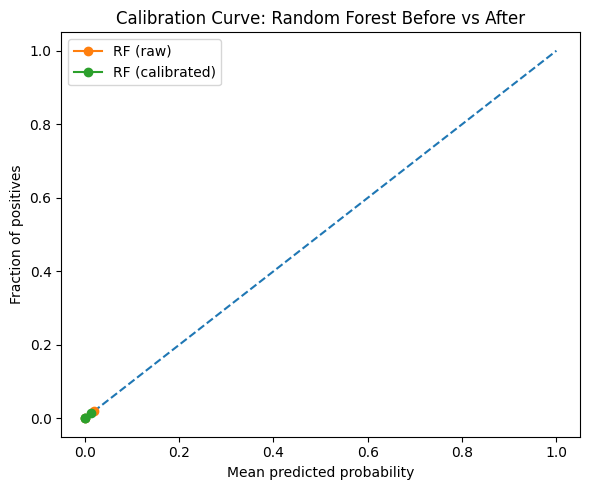

In [ ]:
def plot_cal(y_true, proba, label):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)

plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1],"--")
plot_cal(y_test, proba_rf, "RF (raw)")
plot_cal(y_test, proba_rf_cal, "RF (calibrated)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve: Random Forest Before vs After")
plt.legend()
plt.tight_layout()
plt.show()

**Observations**

The plot shows both curves hugging near the bottom-left. That’s expected because:
* Fraud is rare, so the **fraction of positives** in most bins is near zero.
* With quantile binning, most predictions are small probabilities.

**Main takeaway:**
* Calibration makes probability estimates more consistent with observed outcomes, but the visual curve may still appear compressed due to extreme imbalance.

**Summary**

I calibrated the Random Forest probabilities using Platt scaling (sigmoid). Calibration preserved ranking performance (PR-AUC remained ~0.814) and did not change matched-alert operational performance (TP=78, FP=24, FN=17 at 102 alerts), which is expected because top-N alerting depends primarily on score ordering. Calibration does, however, improve probability interpretability: in highly imbalanced fraud settings, calibrated probabilities are typically very small in absolute value, so thresholds (e.g., ~0.001) should be interpreted relative to the base rate rather than as absolute “risk percentages.”

**Feature importances from the trained RF**

In [ ]:
# RF is already trained: rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 15 RF feature importances:")
display(importances.head(15))

# Optional: full list
# display(importances)

Top 15 RF feature importances:


,0
V14,0.184069
V10,0.119000
V12,0.102195
V4,0.101242
V17,0.088722
V11,0.067643
V3,0.055561
V16,0.048853
V2,0.027075
V7,0.026403


**Observations**

#####**Feature importance interpretation**

Top Drivers:
* V14 (0.184) is the strongest signal by far
* Next: V10 (0.119), V12 (0.102), V4 (0.101), V17 (0.089), V11 (0.068), V3 (0.056), V16 (0.049)
* Amount and Time are not in the top 15, meaning the model is relying more on the anonymized transaction pattern components than raw amount/time.

#####**Final operating policy**

**Insight: How does the business actually use the model day-to-day?**

✅ **Recommended policy: Review top-N highest-risk transactions**
* **Policy:** “Review the top 102 highest-risk transactions per batch (or per day/hour)”
* **Why:** N maps directly to review capacity, and avoids confusion about the absolute meaning of tiny calibrated probabilities in rare-event problems.

Thresholds is an equivalent implementation detail:
* “This corresponds to a learned threshold that changes slightly over time.”

#####**Final model choice**

✅ **Final model: Random Forest (calibrated)**
* RF had the best PR-AUC and best operational performance at the same alert budget.
* Calibration improves probability interpretability for dashboards/risk scoring.

#####**Costs & benefits line**

With an alert budget of 102 transactions (0.18% of traffic), the system catches 78/95 frauds (82.1% recall) with only 24 false alarms (76.5% precision). That’s 1.31 alerts per fraud caught and 0.31 false positives per fraud caught.

#####**Final Operating Policy and Model Selection**
* **Operating policy (capacity-based):** Review the top 102 highest-risk transactions (rank-based alerting), which aligns directly with investigator capacity and avoids relying on absolute probability thresholds in a rare-event setting.
* **Final model: Random Forest (calibrated)**, selected for the best PR-AUC and strongest operational performance at a fixed alert budget.
* **Business impact:** At 102 alerts (0.18% of transactions), the model catches 78/95 frauds (82.1% recall) with 24 false alarms (76.5% precision)—providing high fraud capture with minimal customer friction and manageable review workload.

**Summary**

Random Forest feature importances show the fraud signal is dominated by a small set of anonymized PCA-like components (V14, V10, V12, V4, V17). Because these features are anonymized, I interpret them as ‘high-signal transaction patterns’ rather than human-readable attributes. Notably, Amount/Time are not top drivers, suggesting the learned decision boundary is pattern-based rather than driven solely by transaction size.

**Visual top importances**

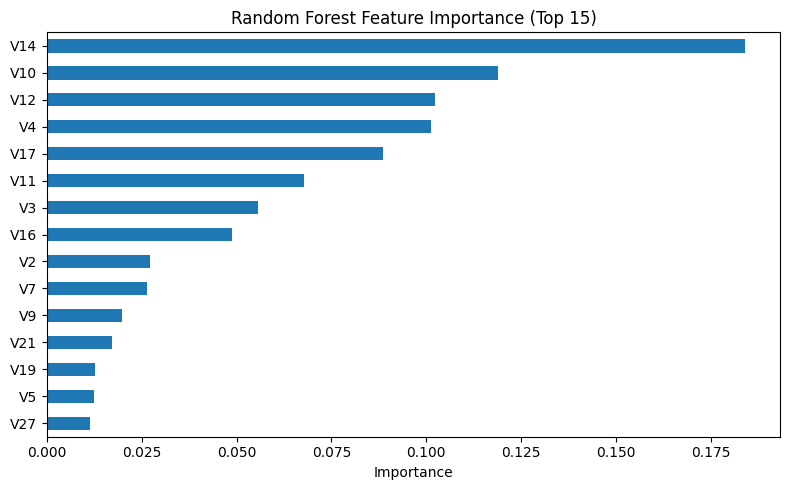

In [ ]:
top_n = 15
plt.figure(figsize=(8,5))
importances.head(top_n).sort_values().plot(kind="barh")
plt.title(f"Random Forest Feature Importance (Top {top_n})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Insights**

The Random Forest model’s feature importances indicate which transaction signals are most predictive of fraud. Because the V1–V28 features are anonymized/PCA-transformed components, I interpret these as “high-signal transaction patterns” rather than human-readable fields. I still validate whether Amount and Time contribute meaningfully, since these are directly interpretable. These importances help identify which dimensions drive the model’s ranking and support monitoring for drift over time.